# Trabajo Practico 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Defino los or y and
X_and = np.array([[-1,-1],
                  [-1,1],
                  [1,-1],
                  [1,1]])
y_and = np.array([-1,
                  -1,
                  -1,
                   1])

X_or = np.array([[-1,-1],
                 [-1, 1],
                 [1, -1],
                 [1, 1]])
y_or = np.array([-1,
                  1,
                  1,
                  1])


X_and_4= np.array( [
    [-1, -1, -1, -1],
    [-1, -1, -1,  1],
    [-1, -1,  1, -1],
    [-1, -1,  1,  1],
    [-1,  1, -1, -1],
    [-1,  1, -1,  1],
    [-1,  1,  1, -1],
    [-1,  1,  1,  1],
    [ 1, -1, -1, -1],
    [ 1, -1, -1,  1],
    [ 1, -1,  1, -1],
    [ 1, -1,  1,  1],
    [ 1,  1, -1, -1],
    [ 1,  1, -1,  1],
    [ 1,  1,  1, -1],
    [ 1,  1,  1,  1]
])

y_and_4 = np.array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1])

X_or_4 = np.array([
    [-1, -1, -1, -1],
    [-1, -1, -1,  1],
    [-1, -1,  1, -1],
    [-1, -1,  1,  1],
    [-1,  1, -1, -1],
    [-1,  1, -1,  1],
    [-1,  1,  1, -1],
    [-1,  1,  1,  1],
    [ 1, -1, -1, -1],
    [ 1, -1, -1,  1],
    [ 1, -1,  1, -1],
    [ 1, -1,  1,  1],
    [ 1,  1, -1, -1],
    [ 1,  1, -1,  1],
    [ 1,  1,  1, -1],
    [ 1,  1,  1,  1]
])

y_or_4 = np.array([-1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
def sign_activation(h):
    y = np.where(h >= 0, 1, -1)
    return y

def compute_error(y_hat, y):
    squared = np.square(y_hat - y)

    return np.sum(squared)



class Perceptron:
    def __init__(self, eta=0.1, learn_iterations=100, error_min = 0.001):

        self.weights = []
        self.eta = eta  # Learning rate
        self.learn_iterations = learn_iterations  # Numero de iteraciones
        self.error_min = error_min

    def train(self, X, y):
        self.w_0= 0 #bias
        self.weights= np.random.uniform(0,1, size= len(X[0])) #El numero de entradas es el largo de la fila
        error = self.error_min+1
        errors = []
        i=0
        while (i < self.learn_iterations and error>self.error_min ):

            y_hat=[]
            for index in range(len(y)):
                h = np.dot(self.weights,X[index]) + self.w_0
                y_hat_i= sign_activation(h)  # Salida del perceptrón
                dif_y = y[index] - y_hat_i

                # Actualizo pesos
                self.weights += self.eta * dif_y * X[index]
                self.w_0 += self.eta * dif_y

                y_hat.append(y_hat_i)
            y_hat=np.array(y_hat)
            error = compute_error(y_hat=y_hat, y=y)

            errors.append(error)
            i+=1

        return errors

    def predict(self, X):
        prediction = []
        for index in range(len(X)):
            prediction.append(sign_activation(np.dot(self.weights,X[index]) + self.w_0 ))
        return np.array(prediction)

    def plot_decision_boundary(self, X, y):

        x1_vals = np.linspace(-2, 2, 100)
        x2_vals = -(self.weights[0] * x1_vals + self.w_0) / self.weights[1] #wT*x=0

        # Graficar los puntos de datos
        label_1=0
        label_min_1=0
        plt.figure(figsize=(6, 6))
        for i in range(len(X)):

            if y[i] == 1:
                if label_1==0:
                    plt.scatter(X[i][0],X[i][1], color='blue', label="y=1")
                    label_1=1
                else:
                    plt.scatter(X[i][0],X[i][1], color='blue')
            else:
                if label_min_1==0:
                    plt.scatter(X[i][0],X[i][1], color='red',label ="y=-1")
                    label_min_1=1
                else:
                    plt.scatter(X[i][0],X[i][1], color='red')


        # Graficar la frontera de decisión
        plt.plot(x1_vals, x2_vals, color='black', label=r'$w^T x = 0$')
        plt.xlabel(r'$x_1$')
        plt.ylabel(r'$x_2$')
        plt.grid(True)
        plt.title('Perceptron Decision Boundary')
        plt.legend()
        plt.show()

[0.13455287 0.52811074]
[0.02067237 0.94269139]


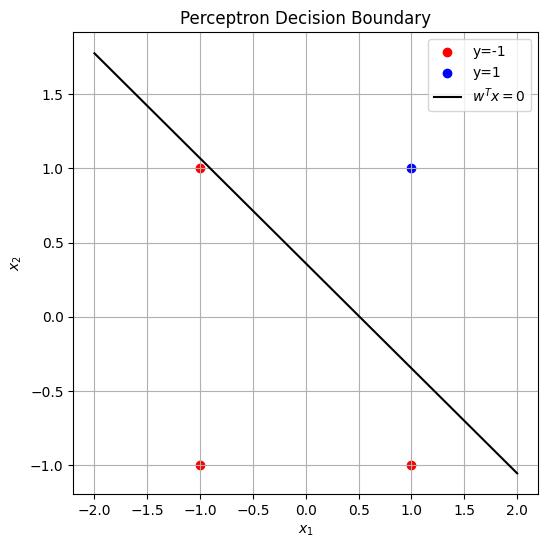

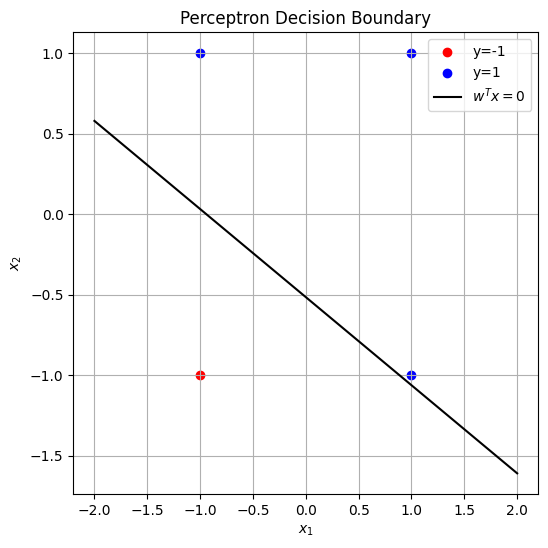

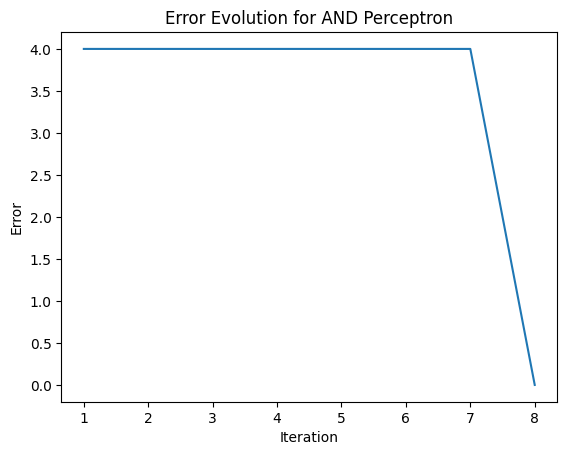

Text(0, 0.5, 'Error')

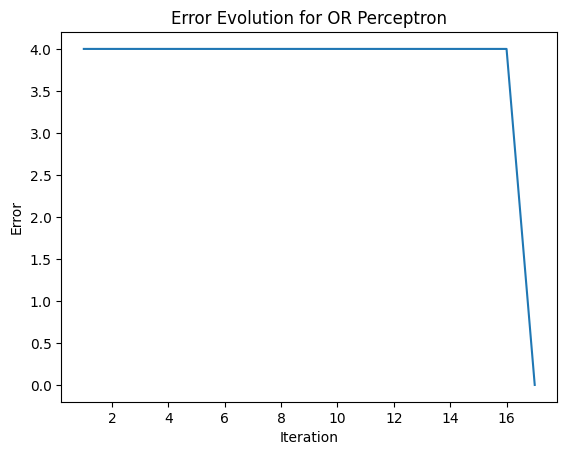

In [ ]:
perceptron_and = Perceptron(eta=0.01, learn_iterations=1000, error_min = 0)
errors_and = perceptron_and.train(X_and, y_and)


perceptron_or = Perceptron(eta=0.01, learn_iterations=1000, error_min = 0)
errors_or = perceptron_or.train(X_or, y_or)


perceptron_and.plot_decision_boundary(X_and, y_and)
perceptron_or.plot_decision_boundary(X_or, y_or)



plt.plot(range(1,len(errors_and)+1,1), errors_and)
plt.title("Error Evolution for AND Perceptron")
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.show()
plt.plot(range(1,len(errors_or)+1,1), errors_or)
plt.title("Error Evolution for OR Perceptron")
plt.xlabel("Iteration")
plt.ylabel("Error")

[0.36086122 0.36365174 0.92022958 0.84295037]
[0.60639452 0.08470851 0.55733554 0.2972097 ]


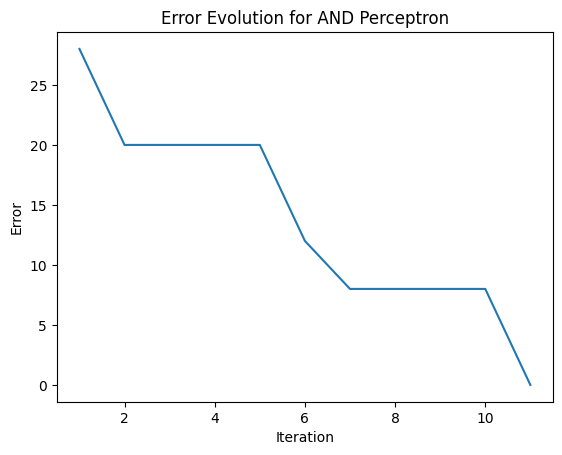

Text(0, 0.5, 'Error')

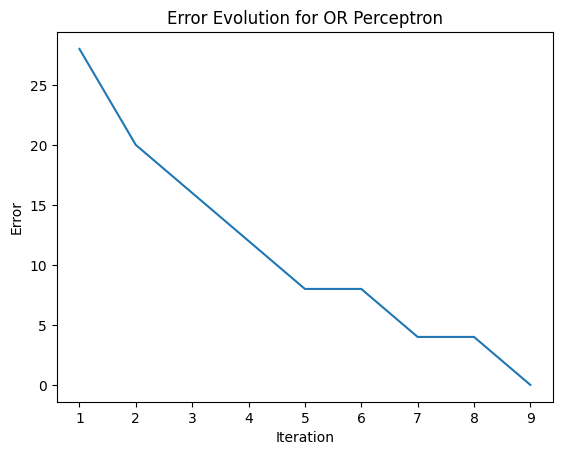

In [ ]:
perceptron_and_4 = Perceptron(eta=0.01, learn_iterations=1000, error_min = 0)
errors_and_4 = perceptron_and_4.train(X_and_4, y_and_4)


perceptron_or_4 = Perceptron(eta=0.01, learn_iterations=1000, error_min = 0)
errors_or_4 = perceptron_or_4.train(X_or_4, y_or_4)





plt.plot(range(1,len(errors_and_4)+1,1), errors_and_4)
plt.title("Error Evolution for AND Perceptron")
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.show()
plt.plot(range(1,len(errors_or_4)+1,1), errors_or_4)
plt.title("Error Evolution for OR Perceptron")
plt.xlabel("Iteration")
plt.ylabel("Error")

## Ejercicio 2
La capacidad de un perceptron simple (separacion con hiperplanos)
\begin{equation}
C(N,N_p)= \frac{\# \text{Problemas lin. separables}}{\# \text{Problemas totales}}
\end{equation}
1) Genero $N_p$ patrones.
\begin{align}
\vec{x}^\mu(i)\in[-1,1], \text{Dist. Uniforme}\\
Y_d^M\in[-1,1],\text{prob}=\frac{1}{2}
\end{align}
2) Entrenar percepción (con condición de corte si es inseparable).
3) Contador de aprendidos. $N_{AP}\leftarrow N_{AP}+1$ si aprendió

In [ ]:
def generate_num_patterns(num_p, dim):

    patterns = []
    labels = np.zeros(num_p)
    for i in range(num_p):
        pattern = np.random.uniform(-1, 1, size=dim)
        label = np.random.choice([-1,1], size = 1, p=[0.5,0.5]).item()
        patterns.append(pattern)
        labels[i]=label
    patterns = np.array(patterns)

    return patterns, labels


def calculate_perceptron_capacity(Np_max,step, Ntot, dimensionality,):
    points = np.arange(0, Np_max, step)
    points[0] = 1
    ratios = []
    for num_p in points:
        N_ap = 0
        for problem_n in range(Ntot):
            patterns, labels = generate_num_patterns(num_p=num_p,dim=dimensionality)


            perceptron = Perceptron(eta=0.01, learn_iterations=200, error_min = 0)
            perceptron.train(patterns, labels)
            prediction = perceptron.predict(patterns)
            if( np.array_equal(prediction,labels)):
                N_ap+=1

        ratios.append(N_ap/Ntot)

    return points,ratios



In [ ]:
N_p_max= 70 #numero de patrones máximo
Ntot = 100 # Número de problemas
dimensionality = 15
points,ratios_15 = calculate_perceptron_capacity(Np_max=N_p_max,step=2,Ntot=Ntot,dimensionality=dimensionality)

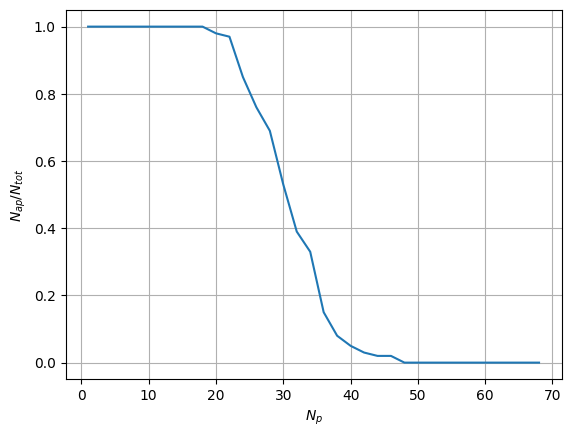

In [ ]:
plt.plot(points, ratios_15)
plt.xlabel(r'$N_p$')
plt.ylabel(r'$N_{ap}/N_{tot}$')
plt.grid()


In [ ]:
index_2N = np.where(points == 15*2)[0].item()
print(index_2N)
print(ratios_15[index_2N])
print("Slope in 2N: ",(ratios_15[index_2N+1]-ratios_15[index_2N-1])/2)

15
0.53
Slope in 2N:  -0.14999999999999997


In [ ]:
N_p_max= 70 #numero de patrones máximo
Ntot = 100 # Número de problemas
dimensionality = 6
points,ratios_6 = calculate_perceptron_capacity(Np_max=N_p_max,step=2,Ntot=Ntot,dimensionality=dimensionality)

In [ ]:
index_2N = np.where(points == dimensionality*2)[0].item()
print(index_2N)
print("Value in 2N: ",ratios_6[index_2N])
print("Slope in 2N: ",(ratios_6[index_2N+1]-ratios_6[index_2N-1])/2)

6
Value in 2N:  0.62
Slope in 2N:  -0.195


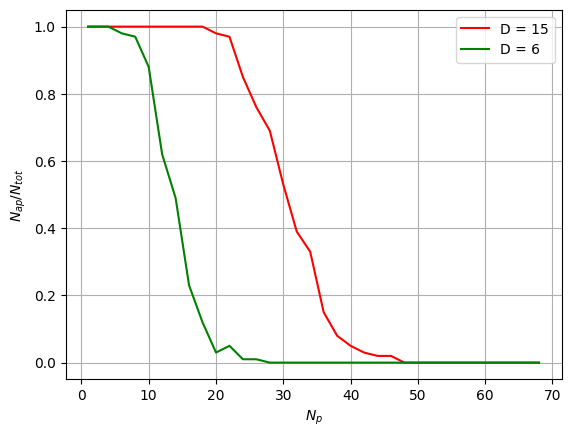

In [ ]:
plt.plot(points, ratios_15, color='r', label='D = 15')
plt.plot(points, ratios_6, color='g', label='D = 6')
plt.xlabel(r'$N_p$')
plt.ylabel(r'$N_{ap}/N_{tot}$')
plt.legend()
plt.grid()

## XOR Backpropagation

In [ ]:
def tanh(x):
    return np.tanh(x)

def derivative_tanh(x):
    return np.ones_like(x) - np.power(np.tanh(x),2)

class PerceptronMulticapaSimple():
    def __init__(self, input_size, hidden_size, output_size):
        self.w1 = np.random.normal(0,0.5,size=[input_size,hidden_size])
        self.w2 = np.random.normal(0,0.5,size =[hidden_size,output_size]).flatten()

        self.b1 = np.random.normal(0,1,size =hidden_size)
        self.b2 = np.random.normal(0,1,size =output_size)

    def forward_pass(self,X):
        list_y_hat = []
        list_hs = []
        list_activations = []
        for x in X:

            h1 = np.matmul(self.w1.T, x) + self.b1
            a1 = tanh(h1)

            h2 = np.matmul(self.w2.T, a1) + self.b2
            a2 = tanh(h2)

            list_activations.append([x,a1,a2])
            list_hs.append([h1,h2])

            y_hat = a2


            list_y_hat.append(y_hat)

        self.activations = list_activations
        self.hs = list_hs

        return list_y_hat

    def backward_pass(self,y,eta):


        for i in range(len(y)):

            delta2 = (self.activations[i][-1] - y[i]) * derivative_tanh(self.hs[i][-1])

            delta1 = derivative_tanh(self.hs[i][-2]) * (self.w2* delta2)



            self.w2 = self.w2 - eta * self.activations[i][-2] * delta2
            self.b2 = self.b2 - eta *  delta2
            self.w1 = self.w1 - eta * np.outer(self.activations[i][0],delta1)
            self.b1 = self.b1 - eta *  delta1




    def train(self, X, y,  learning_rate, max_iterations , error_min):
        y = np.array(y).flatten()
        iteration = 0
        error_evolution = []
        error = error_min+1

        while iteration < max_iterations and error>error_min:
            y_hat = self.forward_pass(X)

            y_hat = np.array(y_hat).flatten()

            error = 0.5*np.sum((y_hat-y)**2)

            self.backward_pass(y, learning_rate)

            error_evolution.append(error)

            iteration+=1

        return error_evolution

    def train_batch(self, X, y,  learning_rate, max_epochs , error_min, batchsize):
        y = np.array(y).flatten()
        epoch = 0
        error_evolution = []
        error_epoch = error_min+1

        while epoch < max_epochs and error_epoch>error_min:
            index_list = range(len(y))
            error_epoch = 0
            while len(index_list)>0:
                if(len(index_list)>batchsize):
                    indices = np.random.choice(index_list, batchsize,replace=False)
                else:
                    indices = index_list

                index_list = [item for item in index_list if item not in indices]

                y_hat = self.forward_pass(X[indices])

                y_hat = np.array(y_hat).flatten()

                error = 0.5*np.sum((y_hat-y[indices])**2)

                self.backward_pass(y[indices], learning_rate)

                error_epoch+=error

            epoch+=1
            error_epoch=error_epoch*batchsize/len(y)
            error_evolution.append(error_epoch)
        return error_evolution






[array([-0.91719143]), array([0.92610998]), array([0.92362538]), array([-0.95719781])]


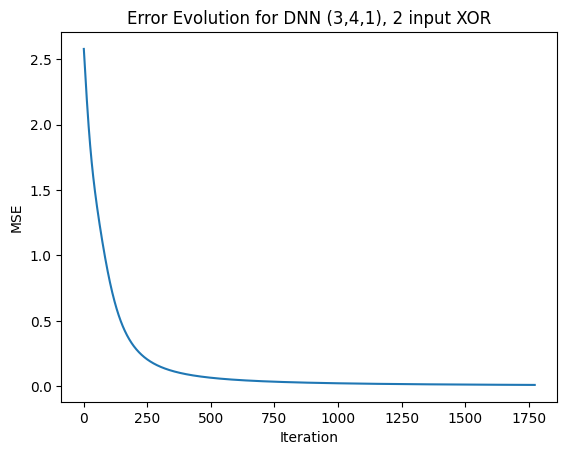

In [ ]:
# XOR 2 entradas
X = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
y = np.array([[-1], [1], [1], [-1]])


perceptron_multi_xor2 = PerceptronMulticapaSimple(input_size=2, hidden_size=4, output_size=1)
error_evolution_xor2 = perceptron_multi_xor2.train(X, y, learning_rate=0.01, error_min=0.01,max_iterations=100000)
print(perceptron_multi_xor2.forward_pass(X))


plt.plot(error_evolution_xor2)
plt.title("Error Evolution for DNN (3,4,1), 2 input XOR")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.show()

## XOR DE 4 ENTRADAS

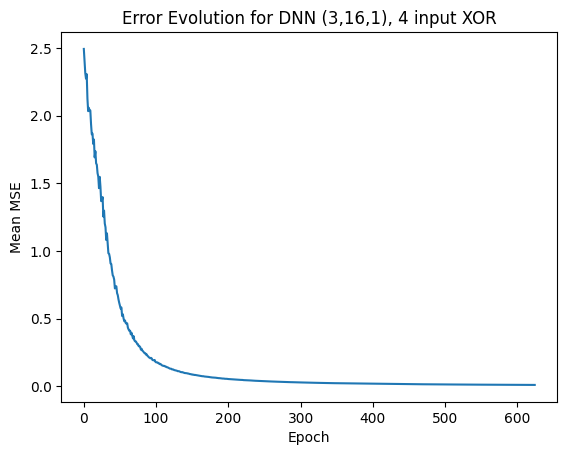

In [ ]:
# Define 4-input XOR data
X = np.array([
    [-1, -1, -1, -1],
    [-1, -1, -1, 1],
    [-1, -1, 1, -1],
    [-1, -1, 1, 1],
    [-1, 1, -1, -1],
    [-1, 1, -1, 1],
    [-1, 1, 1, -1],
    [-1, 1, 1, 1],
    [1, -1, -1, -1],
    [1, -1, -1, 1],
    [1, -1, 1, -1],
    [1, -1, 1, 1],
    [1, 1, -1, -1],
    [1, 1, -1, 1],
    [1, 1, 1, -1],
    [1, 1, 1, 1]
])

# XOR output: 1 if odd number of 1s, else -1
y = np.array([-1, 1, 1, -1, 1, -1, -1, 1, 1, -1, -1, 1, -1, 1, 1, -1])

perceptron_multi_xor4 = PerceptronMulticapaSimple(input_size=4, hidden_size=16, output_size=1)
error_evolution_xor4= perceptron_multi_xor4.train_batch(X, y, learning_rate=0.01, error_min=0.01,max_epochs=10000,batchsize=4)


plt.plot(error_evolution_xor4)
plt.title("Error Evolution for DNN (3,16,1), 4 input XOR")
plt.xlabel("Epoch")
plt.ylabel("Mean MSE")
plt.show()

In [ ]:
print(perceptron_multi_xor4.forward_pass(X))
print(error_evolution_xor4[-1])

[array([-0.92170629]), array([0.88160427]), array([0.98490051]), array([-0.93483438]), array([0.94782427]), array([-0.95312688]), array([-0.95698133]), array([0.98022703]), array([0.96369856]), array([-0.89054103]), array([-0.92530044]), array([0.8915552]), array([-0.94839193]), array([0.96211824]), array([0.91714237]), array([-0.92157195])]
0.009978053495505887


## APRENDIZAJE DE FUNCION CONTINUA

In [ ]:
def tanh(x):
    return np.tanh(x)

def derivative_tanh(x):
    return np.ones_like(x) - np.power(np.tanh(x),2)

class PerceptronMulticapaLinear():
    def __init__(self, input_size, hidden_size, output_size):
        self.w1 = np.random.normal(0,0.5,size=[input_size,hidden_size[0]])
        self.w2 = np.random.normal(0,0.5,size =[hidden_size[0],hidden_size[1]])
        self.w3 = np.random.normal(0,0.5,size =[hidden_size[1],output_size]).flatten()

        self.b1 = np.random.normal(0,0.5,size =hidden_size[0])
        self.b2 = np.random.normal(0,0.5,size =hidden_size[1])
        self.b3 = np.random.normal(0,0.5,size =output_size)

    def forward_pass(self,X):
        list_y_hat = []
        list_hs = []
        list_activations = []
        for x in X:

            h1 = np.matmul(self.w1.T, x) + self.b1
            a1 = tanh(h1)

            h2 = np.matmul(self.w2.T, a1) + self.b2
            a2 = tanh(h2)

            h3 = np.matmul(self.w3.T, a2) + self.b3
            a3 = h3

            list_activations.append([x,a1,a2,a3])
            list_hs.append([h1,h2,h3])

            y_hat = a3


            list_y_hat.append(y_hat)

        self.activations = list_activations
        self.hs = list_hs

        return list_y_hat

    def backward_pass(self,y,eta):


        for i in range(len(y)):

            delta3 = (self.activations[i][-1] - y[i])
            delta2 = derivative_tanh(self.hs[i][-2]) * (self.w3* delta3)
            delta1 = derivative_tanh(self.hs[i][-3]) * np.matmul(self.w2, delta2)


            self.w3 = self.w3 - eta * self.activations[i][-2] * delta3
            self.b3 = self.b3 - eta *  delta3


            self.w2 = self.w2 - eta * np.outer(self.activations[i][-3],delta2)
            self.b2 = self.b2 - eta *  delta2

            self.w1 = self.w1 - eta * np.outer(self.activations[i][-4],delta1)
            self.b1 = self.b1 - eta *  delta1




    def train(self, X, y,  learning_rate, max_iterations , error_min):
        y = np.array(y).flatten()
        iteration = 0
        error_evolution = []
        error = error_min+1

        while iteration < max_iterations and error>error_min:
            y_hat = self.forward_pass(X)

            y_hat = np.array(y_hat).flatten()

            error = 0.5*np.sum((y_hat-y)**2)

            self.backward_pass(y, learning_rate)

            error_evolution.append(error)

            iteration+=1

        return error_evolution
    def train_batch(self, X, y,  learning_rate, max_epochs , error_min, batchsize):
        y = np.array(y).flatten()
        epoch = 0
        error_evolution = []
        error_epoch = error_min+1

        while epoch < max_epochs and error_epoch>error_min:
            index_list = range(len(y))
            error_epoch = 0
            while len(index_list)>0:
                if(len(index_list)>batchsize):
                    indices = np.random.choice(index_list, batchsize,replace=False)
                else:
                    indices = index_list

                index_list = [item for item in index_list if item not in indices]

                y_hat = self.forward_pass(X[indices])

                y_hat = np.array(y_hat).flatten()

                error = 0.5*np.sum((y_hat-y[indices])**2)

                self.backward_pass(y[indices], learning_rate)

                error_epoch+=error

            epoch+=1
            error_epoch=error_epoch*batchsize/len(y)
            error_evolution.append(error_epoch)
        return error_evolution






In [ ]:
x_values = np.linspace(0, 2 * np.pi, 10)  # 10 puntos en el rango [0, 2π] para x
y_values = np.linspace(0, 2 * np.pi, 10)  # 10 puntos en el rango [0, 2π] para y
z_values = np.linspace(-1, 1, 10)         # 10 puntos en el rango [-1, 1] para z

# Crear una malla de puntos (x, y, z)
X, Y, Z = np.meshgrid(x_values, y_values, z_values)
X_flat = X.flatten()
Y_flat = Y.flatten()
Z_flat = Z.flatten()

Xtrain = np.column_stack((X_flat, Y_flat, Z_flat))
# Calcular los valores de la función para cada combinación de (x, y, z)
f_values = np.sin(X_flat) + np.cos(Y_flat) + Z_flat


perceptron_multi_Linear = PerceptronMulticapaLinear(input_size=3, hidden_size=[16,16], output_size=1)
error_evolution_linear = perceptron_multi_Linear.train_batch(Xtrain, f_values, learning_rate=0.01, error_min=0.01,max_epochs=1000,batchsize=10)

In [ ]:
batchsize = 7
index_list = range(10)
x_prueba=np.array([10,20,30,40,50,60,70,80,90,100])
y_prueba=np.array([-10,-20,-30,-40,-50,-60,-70,-80,-90,-100])
while len(index_list)>0:
    print("NEW")
    print(index_list)
    if(len(index_list)>batchsize):
        indices = np.random.choice(index_list, batchsize,replace=False)
    else: indices = index_list
    print(indices)
    index_list = [item for item in index_list if item not in indices]
    print(index_list)
    print(x_prueba[indices])
    print(y_prueba[indices])


NEW
range(0, 10)
[4 1 8 9 3 7 5]
[0, 2, 6]
[ 50  20  90 100  40  80  60]
[ -50  -20  -90 -100  -40  -80  -60]
NEW
[0, 2, 6]
[0, 2, 6]
[]
[10 30 70]
[-10 -30 -70]


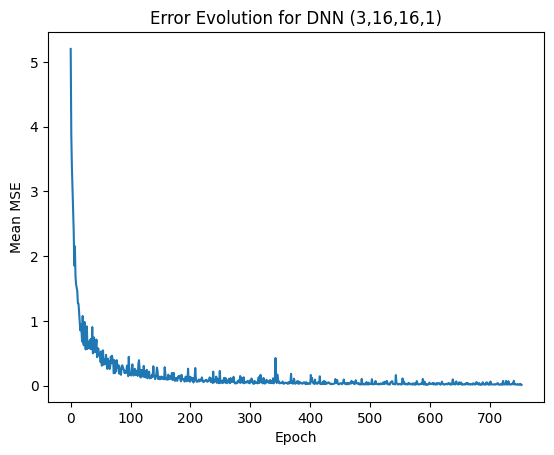

In [ ]:
plt.plot(error_evolution_linear)
plt.title("Error Evolution for DNN (3,16,16,1)")
plt.xlabel("Epoch")
plt.ylabel("Mean MSE")
plt.show()

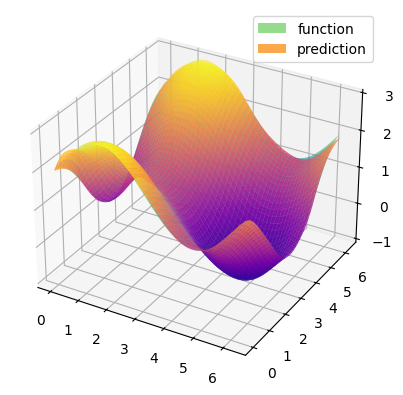

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the x, y, and z ranges
x_values = np.linspace(0, 2 * np.pi, 100)  # 100 points in the range [0, 2π] for x
y_values = np.linspace(0, 2 * np.pi, 100)  # 100 points in the range [0, 2π] for y

# Create meshgrid for X and Y
X, Y = np.meshgrid(x_values, y_values)
Z = np.sin(X) + np.cos(Y)+np.ones_like(X)  # Calculate Z based on X and Y

# Plot the first surface
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7, label = "function")

# Flatten X and Y for input to the perceptron
X_flat = X.flatten()
Y_flat = Y.flatten()
Z_flat = np.ones_like(X_flat)  # Assuming Z values are all 1 for this example

# Stack inputs for perceptron input
Xtest = np.column_stack((X_flat, Y_flat, Z_flat))

# Forward pass through perceptron
ytest = perceptron_multi_Linear.forward_pass(Xtest)
ytest = np.array(ytest)

# Ensure ytest has the correct shape
ytest = ytest.reshape(X.shape)  # Reshape to 100x100

# Plot the second surface
ax.plot_surface(X, Y, ytest, cmap='plasma', alpha=0.9, label ="prediction")
plt.legend()
plt.show()

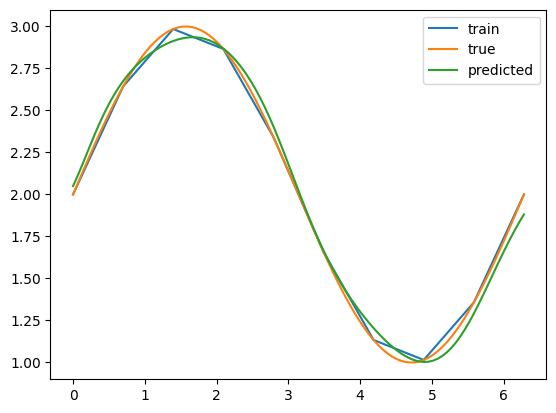

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x_values = np.linspace(0, 2 * np.pi, 10)
y_values = 2*np.pi* np.ones_like(x_values)


f_values = np.sin(x_values) + np.cos(y_values) + np.ones_like(x_values)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x_values,f_values, label="train")

x_values = np.linspace(0, 2 * np.pi, 100)
y_values = 2*np.pi* np.ones_like(x_values)


f_values = np.sin(x_values) + np.cos(y_values) + np.ones_like(x_values)
ax.plot(x_values,f_values, label="true")


X_flat = x_values.flatten()
Y_flat = y_values.flatten()
Z_flat = np.ones_like(X_flat)

Xtest = np.column_stack((X_flat, Y_flat, Z_flat))

ytest = perceptron_multi_Linear.forward_pass(Xtest)
ytest = np.array(ytest)


ytest = ytest.reshape(x_values.shape)


ax.plot(x_values,ytest, label="predicted")
plt.legend()
plt.show()


In [ ]:
print(error_evolution_linear[-1])

0.009940114404854225


### FUNCION CONTINUA CON SOLAMENTE UNA CAPA OCULTA

In [ ]:
def tanh(x):
    return np.tanh(x)

def derivative_tanh(x):
    return np.ones_like(x) - np.power(np.tanh(x),2)

class PerceptronMulticapaLinearSimple():
    def __init__(self, input_size, hidden_size, output_size):
        self.w1 = np.random.normal(0,0.5,size=[input_size,hidden_size])
        self.w2 = np.random.normal(0,0.5,size =[hidden_size,output_size]).flatten()

        self.b1 = np.random.normal(0,0.5,size =hidden_size)
        self.b2 = np.random.normal(0,0.5,size =output_size)


    def forward_pass(self,X):
        list_y_hat = []
        list_hs = []
        list_activations = []
        for x in X:

            h1 = np.matmul(self.w1.T, x) + self.b1
            a1 = tanh(h1)

            h2 = np.matmul(self.w2.T, a1) + self.b2
            a2 = h2

            list_activations.append([x,a1,a2])
            list_hs.append([h1,h2])

            y_hat = a2


            list_y_hat.append(y_hat)

        self.activations = list_activations
        self.hs = list_hs

        return list_y_hat

    def backward_pass(self,y,eta):


        for i in range(len(y)):

            delta2 = (self.activations[i][-1] - y[i])
            delta1 = derivative_tanh(self.hs[i][-2]) * (self.w2* delta2)



            self.w2 = self.w2 - eta * self.activations[i][-2] * delta2
            self.b2 = self.b2 - eta *  delta2

            self.w1 = self.w1 - eta * np.outer(self.activations[i][-3],delta1)
            self.b1 = self.b1 - eta *  delta1




    def train(self, X, y,  learning_rate, max_iterations , error_min):
        y = np.array(y).flatten()
        iteration = 0
        error_evolution = []
        error = error_min+1

        while iteration < max_iterations and error>error_min:
            y_hat = self.forward_pass(X)

            y_hat = np.array(y_hat).flatten()

            error = 0.5*np.sum((y_hat-y)**2)

            self.backward_pass(y, learning_rate)

            error_evolution.append(error)

            iteration+=1

        return error_evolution
    def train_batch(self, X, y,  learning_rate, max_epochs , error_min, batchsize):
        y = np.array(y).flatten()
        epoch = 0
        error_evolution = []
        error_epoch = error_min+1

        while epoch < max_epochs and error_epoch>error_min:
            index_list = range(len(y))
            error_epoch = 0
            while len(index_list)>0:
                if(len(index_list)>batchsize):
                    indices = np.random.choice(index_list, batchsize,replace=False)
                else:
                    indices = index_list

                index_list = [item for item in index_list if item not in indices]

                y_hat = self.forward_pass(X[indices])

                y_hat = np.array(y_hat).flatten()

                error = 0.5*np.sum((y_hat-y[indices])**2)

                self.backward_pass(y[indices], learning_rate)

                error_epoch+=error

            epoch+=1
            error_epoch=error_epoch/batchsize
            error_evolution.append(error_epoch)
        return error_evolution



In [ ]:
x_values = np.linspace(0, 2 * np.pi, 4)  # 10 puntos en el rango [0, 2π] para x
y_values = np.linspace(0, 2 * np.pi, 4)  # 10 puntos en el rango [0, 2π] para y
z_values = np.linspace(-1, 1, 3)         # 10 puntos en el rango [-1, 1] para z

# Crear una malla de puntos (x, y, z)
X, Y, Z = np.meshgrid(x_values, y_values, z_values)
X_flat = X.flatten()
Y_flat = Y.flatten()
Z_flat = Z.flatten()

Xtrain = np.column_stack((X_flat, Y_flat, Z_flat))
# Calcular los valores de la función para cada combinación de (x, y, z)
f_values = np.sin(X_flat) + np.cos(Y_flat) + Z_flat

perceptron_multi_LinearSimple = PerceptronMulticapaLinearSimple(input_size=3, hidden_size=30, output_size=1)
error_evolution_linearSimple = perceptron_multi_LinearSimple.train_batch(Xtrain, f_values, learning_rate=0.001, error_min=0.01,max_epochs=10000,batchsize=1)

0.009689191234130617


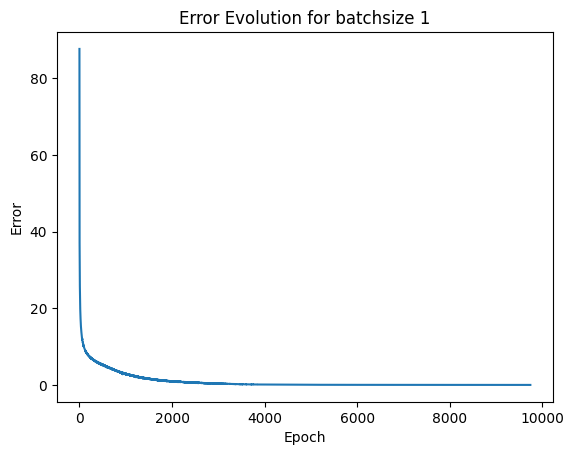

In [ ]:
plt.plot(error_evolution_linearSimple)
plt.title("Error Evolution for batchsize 1")
plt.ylabel("Error")
plt.xlabel("Epoch")
print(error_evolution_linearSimple[-1])

In [ ]:
perceptron_multi_LinearSimple = PerceptronMulticapaLinearSimple(input_size=3, hidden_size=30, output_size=1)
error_evolution_linearSimple = perceptron_multi_LinearSimple.train_batch(Xtrain, f_values, learning_rate=0.001, error_min=0.01,max_epochs=10000,batchsize=40)

0.00985231117552175


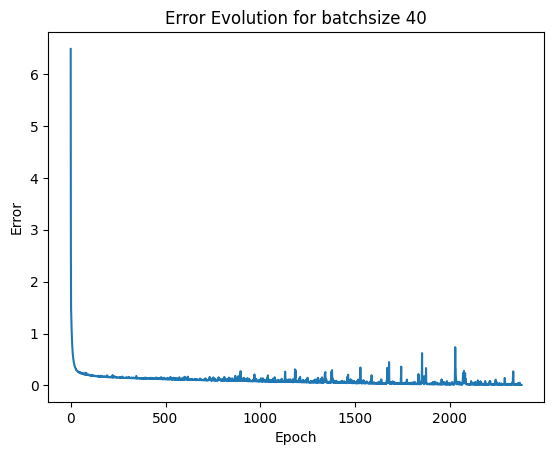

In [ ]:
plt.plot(error_evolution_linearSimple)
plt.title("Error Evolution for batchsize 40")
plt.ylabel("Error")
plt.xlabel("Epoch")
print(error_evolution_linearSimple[-1])

## BOLTZMANN MACHINE

In [ ]:
import scipy.io
import numpy as np
trainMNIST = scipy.io.loadmat('datosTrain.mat')
testMNIST = scipy.io.loadmat('datosTest.mat')
trainMNIST = trainMNIST['data']
testMNIST = testMNIST['data']

200


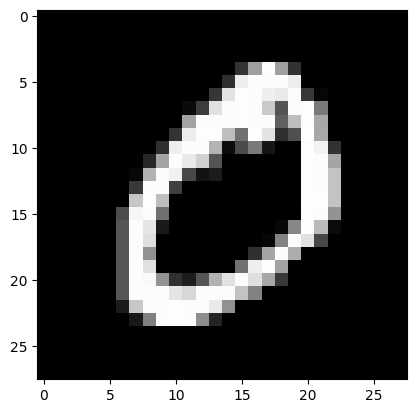

In [ ]:
print(len(trainMNIST))
image = trainMNIST[0].reshape((28, 28))
fig = plt.figure
plt.imshow(image, cmap='gray')
plt.show()


In [ ]:
from sklearn.utils import gen_batches
def sigmoid(x):
    return np.ones_like(x)/(np.ones_like(x)+np.exp(-x))


class MaquinaBoltzmann():


    def __init__(self, visible_dim, hidden_dim):
        self.visible_dim = visible_dim
        self.hidden_dim = hidden_dim
        # weights
        self.W = np.random.normal(0,0.25,size=[visible_dim, hidden_dim])
        # biases
        self.bh = np.random.normal(0,0.25,size=hidden_dim)
        self.bv = np.random.normal(0,0.25,size=visible_dim)


    def train(self, X, epochs=10, batch_dim=16, lr=0.01):
        error_epochs=[]
        for epoch in range(epochs):
            if epoch ==round(epochs/2):
                lr=lr/10

            error_epoch = 0
            batches = list(gen_batches(X.shape[0], batch_dim))

            for batch in batches:
                batch = X[batch.start:batch.stop]
                batch_size = batch.shape[0]

                v_init = np.random.normal(batch,np.ones_like(batch),size=batch.shape)


                #forward
                #20 times 784, 784 times 100
                sum_h=np.matmul(v_init,self.W) + self.bh #20 times 100
                h_forward1 = sigmoid(sum_h)
                h_forward1 = np.where(h_forward1 > np.random.uniform(0,1,size=h_forward1.shape), 1, 0)

                #backward
                #20 times 100, 100 times 784
                sum_v =np.matmul(h_forward1, self.W.T)+self.bv #20 times 784
                #v_back = sigmoid(sum_v)
                v_back = np.random.normal(sum_v,np.ones_like(batch),size=batch.shape)

                #forward 2
                #20 times 784, 784 times 100
                sum_h =np.matmul(v_back,self.W) + self.bh #20 times 100
                h_forward2 = sigmoid(sum_h)
                h_forward2 = np.where(h_forward2 > np.random.uniform(0,1,size=h_forward2.shape), 1, 0)


                #784 times 20, 20 times 100
                update_forward = np.matmul(v_init.T, h_forward1)#784 times 100

                #784 times 20, 20 times 100
                update_backward = np.matmul(v_back.T, h_forward2) #784 times 100

                # Error
                error = np.sum((v_init-v_back)**2)/batch_size

                # Update
                self.W += lr*(update_forward-update_backward)/batch_size
                self.bh += lr*(np.sum(h_forward1-h_forward2, axis=0))/batch_size
                self.bv += lr*(np.sum(v_init-v_back, axis=0))/batch_size

                error_epoch += error

            error_epoch /= len(batches)
            #print(f"epoch: {epoch}/{epochs} \t{'error:'} {error_epoch}")
            error_epochs.append(error_epoch)
        return error_epochs

    def reconstruct(self, X):

        #forward
        #20 times 784, 784 times 100
        sum_h=np.matmul(X,self.W) + self.bh #20 times 100
        h_forward1 = sigmoid(sum_h)



        #backward
        #20 times 100, 100 times 784
        sum_v =np.matmul(h_forward1, self.W.T)+self.bv #20 times 784
        v_back = sigmoid(sum_v)

        return v_back






In [ ]:
trainMNIST_bin = np.where(trainMNIST > 0.5, 1, 0)
mb = MaquinaBoltzmann(len(trainMNIST[0]),100)


error_evol = mb.train(trainMNIST_bin, lr = 0.005,batch_dim=6,epochs=100)
print(mb.W.max())
print(mb.W.min())

0.6620654309018483
-0.5942936541303375


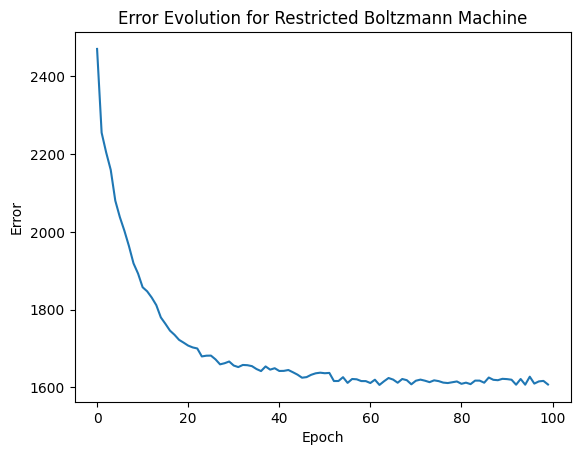

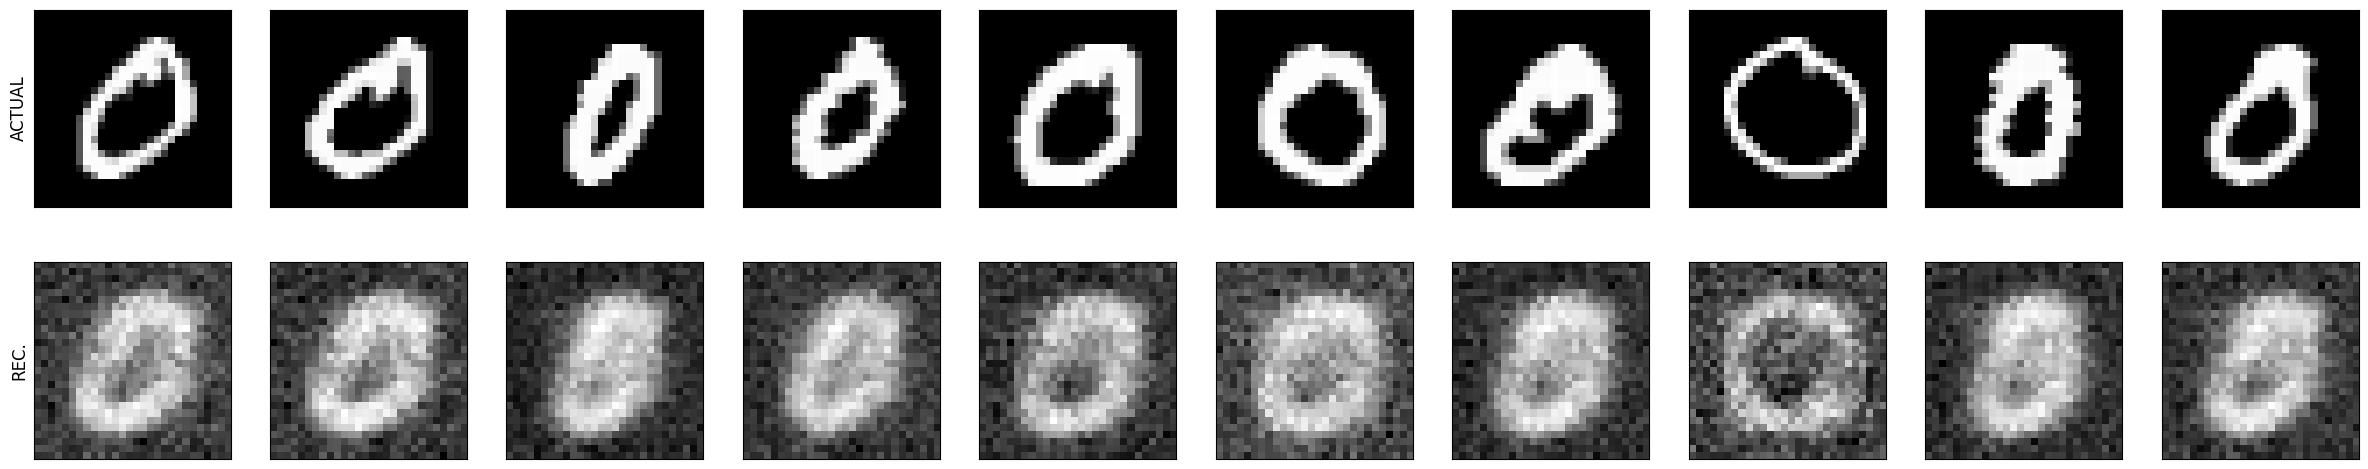

In [ ]:
plt.plot(error_evol)
plt.title("Error Evolution for Restricted Boltzmann Machine")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.show()
reconstructed = mb.reconstruct(trainMNIST_bin)

# show 10 sample images
rows = 2
columns = 10

fig, axes = plt.subplots(rows, columns,sharey = True,figsize=(30, 6))
for i in range(rows):
    for j in range(columns):
        if i==0:
          axes[i, j].imshow(trainMNIST[j].reshape(28, 28), cmap='gray')
        else:
          axes[i, j].imshow(reconstructed[j].reshape(28, 28), cmap='gray')

        axes[i, j].tick_params(left = False, right = False , labelleft = False,
                labelbottom = False, bottom = False)

axes[0, 0].set_ylabel("ACTUAL", fontsize=12)
axes[1, 0].set_ylabel("REC.", fontsize=12)
plt.show()

In [ ]:
from sklearn.utils import gen_batches

class RBM():

  def __init__(self, visible_dim, hidden_dim):
    self.visible_dim = visible_dim
    self.hidden_dim = hidden_dim
    # weights
    self.W = np.random.randn(visible_dim, hidden_dim)
    # biases
    self.bh = np.random.randn(hidden_dim)
    self.bv = np.random.randn(visible_dim)


  def train(self, X, epochs=10, batch_dim=16, lr=0.01):
    error_epochs=[]
    for epoch in range(epochs):

      error_epoch = 0
      batches = list(gen_batches(X.shape[0], batch_dim))

      for batch in batches:
        batch = X[batch.start:batch.stop]
        batch_size = batch.shape[0]

        v_init = batch


        #forward
        #20 times 784, 784 times 100
        sum_h=np.matmul(v_init,self.W) + self.bh #20 times 100
        h_forward1 = sigmoid(sum_h)


        #backward
        #20 times 100, 100 times 784
        sum_v =np.matmul(h_forward1, self.W.T)+self.bv #20 times 784
        v_back = sigmoid(sum_v)

        #forward 2
        #20 times 784, 784 times 100
        sum_h =np.matmul(v_back,self.W) + self.bh #20 times 100
        h_forward2 = sigmoid(sum_h)


        #784 times 20, 20 times 100
        update_forward = np.matmul(v_init.T, h_forward1)#784 times 100

        #784 times 20, 20 times 100
        update_backward = np.matmul(v_back.T, h_forward2) #784 times 100

        # Error
        error = np.sum((v_init-v_back)**2)/batch_size

        # Update
        self.W += lr*(update_forward-update_backward)/batch_size
        self.bh += lr*(np.sum(h_forward1-h_forward2, axis=0))/batch_size
        self.bv += lr*(np.sum(v_init-v_back, axis=0))/batch_size

        error_epoch += error

      error_epoch /= len(batches)
      #print(f"epoch: {epoch}/{epochs} \t{'error:'} {error_epoch}")
      error_epochs.append(error_epoch)
    return error_epochs

  def reconstruct(self, X):

    #forward
    #20 times 784, 784 times 100
    sum_h=np.matmul(X,self.W) + self.bh #20 times 100
    h_forward1 = sigmoid(sum_h)



    #backward
    #20 times 100, 100 times 784
    sum_v =np.matmul(h_forward1, self.W.T)+self.bv #20 times 784
    v_back = sigmoid(sum_v)

    return v_back






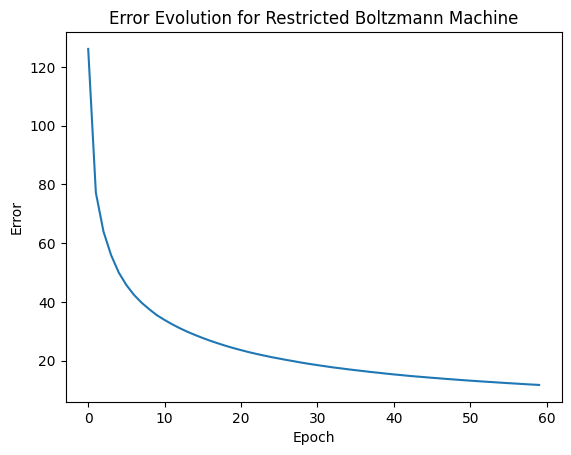

In [ ]:
# binarize data
trainMNIST_bin = np.where(trainMNIST > 0.5, 1, 0)
rbm = RBM(visible_dim=trainMNIST_bin.shape[1], hidden_dim=100)
# Train the RBM
error_epochs = rbm.train(trainMNIST_bin, epochs=60, batch_dim=20, lr=0.4)


plt.plot(error_epochs)
plt.title("Error Evolution for Restricted Boltzmann Machine")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.show()

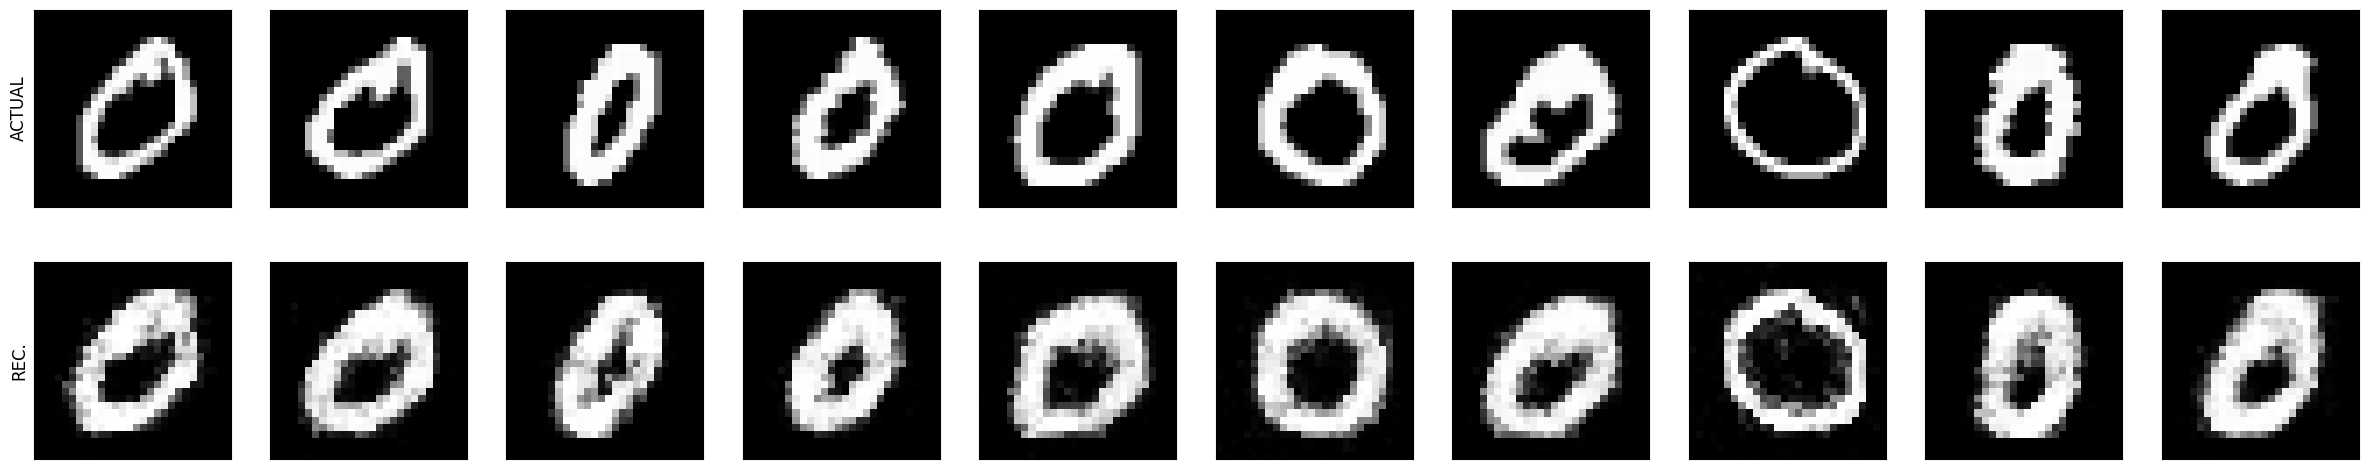

In [ ]:
reconstructed = rbm.reconstruct(trainMNIST_bin)

# show 10 sample images
rows = 2
columns = 10

fig, axes = plt.subplots(rows, columns,sharey = True,figsize=(30, 6))
for i in range(rows):
    for j in range(columns):
        if i==0:
          axes[i, j].imshow(trainMNIST[j].reshape(28, 28), cmap='gray')
        else:
          axes[i, j].imshow(reconstructed[j].reshape(28, 28), cmap='gray')

        axes[i, j].tick_params(left = False, right = False , labelleft = False,
                labelbottom = False, bottom = False)

axes[0, 0].set_ylabel("ACTUAL", fontsize=12)
axes[1, 0].set_ylabel("REC.", fontsize=12)
plt.show()

##  RED NEURONAL CONVOLUCIONAL

\begin{equation}
softmax(x,i) = \frac{e^{x(i)}}{\sum_j e^{x(j)}}
\end{equation}

\begin{equation}
D_{KL}(p||q) = H(p,q) + H(p) = H(p,q)
\end{equation}

\begin{equation}
H(p,q) = - \sum_x p(x)\log(q(x))
\end{equation}

p:distribucion objetivo

q:distribucion estimada por la red (salida softmax)


Entrene una red convolucional para clasificar las imágenes de la base de datos MNIST.

¿Cuál es la red convolucional más pequeña que puede conseguir con una exactitud de al menos 90% en el conjunto de evaluación? ¿Cuál es el perceptrón multicapa más pequeño que puede conseguir con la misma exactitud?

In [ ]:
import torch as th
import torch.nn as nn
import torch.nn.functional as F

class conv(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=2, stride=1, padding=0)
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=3)
        self.conv2 = nn.Conv2d(1, 3, 2)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(48, 10)


        self.optimizer = th.optim.Adam(self.parameters(), lr=0.001)
        self.f_loss = nn.CrossEntropyLoss()



    def _make_minibatches(self,training_data, training_labels, minibatch_size):
        mini_batches = []
        label_batches = []


        permutation = th.randperm(training_data.size(0))
        training_data = training_data[permutation]
        training_labels = training_labels[permutation]

        n_minibatches = 0
        for i in range(0, training_data.size(0), minibatch_size):
            mini_batch_data = training_data[i:i+minibatch_size]
            mini_batch_labels = training_labels[i:i+minibatch_size]
            mini_batches.append(mini_batch_data)
            label_batches.append(mini_batch_labels)
            n_minibatches +=1

        return mini_batches, label_batches, n_minibatches

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = th.flatten(x, 1)
        x = self.fc1(x)
        return x

    def train(self, training_data,training_labels, minibatch_size,number_epochs):
        loss_evolution = []
        for epoca in range(number_epochs):
            mini_batches, labels,n_minibatches = self._make_minibatches(training_data, training_labels, minibatch_size)
            loss_epoch = 0
            for mini_batch in range(n_minibatches):
                outputs = self.forward(mini_batches[mini_batch].reshape(minibatch_size, 1, 28, 28))
                loss = self.f_loss(outputs, labels[mini_batch])

                loss_epoch+=loss/n_minibatches
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

            loss_evolution.append(loss_epoch)

        return loss_evolution



In [ ]:
training_data = th.load('MNIST_training_data.pt').to(th.float32)
training_labels = th.load('MNIST_training_labels.pt')
test_data = th.load('MNIST_test_data.pt').to(th.float32)
test_labels = th.load('MNIST_test_labels.pt')

C:\Users\Marcos\AppData\Local\Temp\ipykernel_19588\3254403422.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  training_data = th.load('MNIST_training_data.pt').to(th.flo

In [ ]:

modelo = conv()

loss_evolution = modelo.train(training_data = training_data,training_labels = training_labels , minibatch_size=100,number_epochs=100)


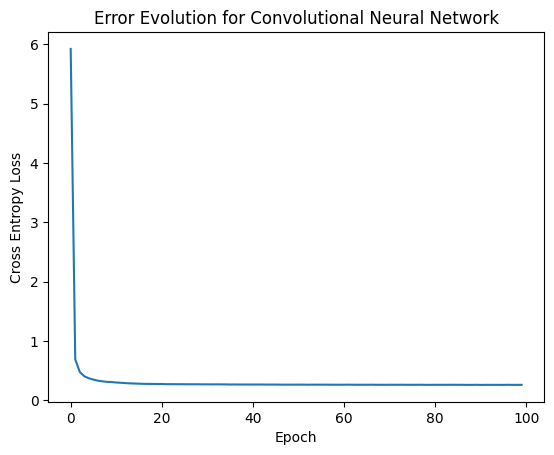

In [ ]:
import matplotlib.pyplot as plt
loss_evolution = th.tensor(loss_evolution)
plt.plot(loss_evolution.numpy())
plt.title("Error Evolution for Convolutional Neural Network")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.show()

In [ ]:
with th.inference_mode():
    labels_pred = modelo.forward(test_data.reshape(10000,1, 28, 28))
    class_predictions = []
    for prediction in labels_pred:

        index_max = th.argmax(prediction)
        class_predictions.append(index_max)


    amount_wrong = 0
    for prediction_index in range(len(class_predictions)):
        if test_labels[prediction_index] != class_predictions[prediction_index]:
            amount_wrong+=1


    accuracy =(len(class_predictions)-amount_wrong)/len(class_predictions)
    print("accuracy:", accuracy*100)

accuracy: 91.63


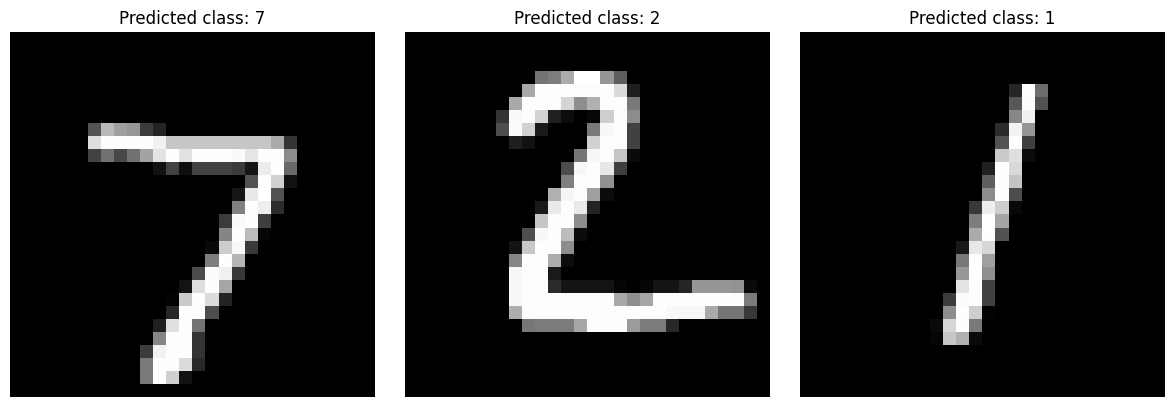

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))  # Create 1 row and 3 columns of subplots

for i in range(3):
    axes[i].imshow(test_data[i], cmap='gray')
    axes[i].set_title(f"Predicted class: {th.argmax(labels_pred[i]).item()}")
    axes[i].axis('off')  # Turn off axes for better visualization

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()

In [ ]:
class Linearforward(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 300)
        self.fc2 = nn.Linear(300, 10)


        self.optimizer = th.optim.Adam(self.parameters(), lr=0.0003)
        self.f_loss = nn.CrossEntropyLoss()



    def _make_minibatches(self,training_data, training_labels, minibatch_size):
        mini_batches = []
        label_batches = []


        permutation = th.randperm(training_data.size(0))
        training_data = training_data[permutation]
        training_labels = training_labels[permutation]

        n_minibatches = 0
        for i in range(0, training_data.size(0), minibatch_size):
            mini_batch_data = training_data[i:i+minibatch_size]
            mini_batch_labels = training_labels[i:i+minibatch_size]
            mini_batches.append(mini_batch_data)
            label_batches.append(mini_batch_labels)
            n_minibatches +=1

        return mini_batches, label_batches, n_minibatches

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        return x

    def train(self, training_data,training_labels, minibatch_size,number_epochs):
        loss_evolution = []
        for epoca in range(number_epochs):
            mini_batches, labels,n_minibatches = self._make_minibatches(training_data, training_labels, minibatch_size)
            loss_epoch = 0
            for mini_batch in range(n_minibatches):
                outputs = self.forward(mini_batches[mini_batch].reshape(minibatch_size,784))
                loss = self.f_loss(outputs, labels[mini_batch])

                loss_epoch+=loss/n_minibatches
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

            loss_evolution.append(loss_epoch)

        return loss_evolution



In [ ]:
modelo_lin= Linearforward()

loss_evolution_lin = modelo_lin.train(training_data = training_data,training_labels = training_labels , minibatch_size=50,number_epochs=30)


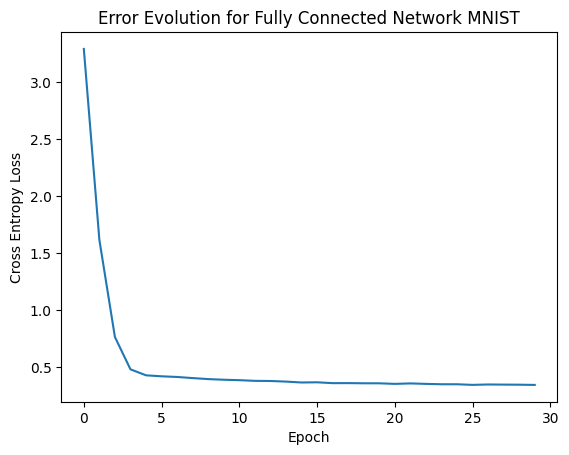

In [ ]:
import matplotlib.pyplot as plt
loss_evolution_lin = th.tensor(loss_evolution_lin)
plt.plot(loss_evolution_lin.numpy())
plt.title("Error Evolution for Fully Connected Network MNIST")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.show()

In [ ]:
with th.inference_mode():
    labels_pred = modelo_lin.forward(test_data.reshape(10000,784))
    class_predictions = []
    for prediction in labels_pred:

        index_max = th.argmax(prediction)
        class_predictions.append(index_max)


    amount_wrong = 0
    for prediction_index in range(len(class_predictions)):
        if test_labels[prediction_index] != class_predictions[prediction_index]:
            amount_wrong+=1


    accuracy =(len(class_predictions)-amount_wrong)/len(class_predictions)
    print("accuracy:", accuracy*100)

accuracy: 90.84


## Autoencoder

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder1 = nn.Linear(784, 392)
        self.encoder2 = nn.Linear(392, 196)
        self.encoder3 = nn.Linear(196, 120)
        self.decoder1 = nn.Linear(120, 196)
        self.decoder2 = nn.Linear(196, 392)
        self.decoder3 = nn.Linear(392, 784)

        self.activation = nn.ReLU()
        self.activation2 = nn.Sigmoid()

        self.optimizer = th.optim.Adam(self.parameters(), lr=0.0005)
        self.f_loss = nn.MSELoss()



    def _make_minibatches(self,training_data, training_labels, minibatch_size):
        mini_batches = []
        label_batches = []

        permutation = th.randperm(training_data.size(0))
        training_data = training_data[permutation]
        training_labels = training_labels[permutation]

        n_minibatches = 0
        for i in range(0, training_data.size(0), minibatch_size):
            mini_batch_data = training_data[i:i+minibatch_size]
            mini_batch_labels = training_labels[i:i+minibatch_size]
            mini_batches.append(mini_batch_data)
            label_batches.append(mini_batch_labels)
            n_minibatches +=1

        return mini_batches, label_batches, n_minibatches

    def forward(self, x):
        x = self.encoder1(x)
        x = self.encoder2(x)
        x = self.encoder3(x)
        x = self.decoder1(x)
        x = self.decoder2(x)
        x = self.decoder3(x)
        return x

    def train(self, training_data,training_labels, minibatch_size,number_epochs):
        loss_evolution = []
        for epoca in range(number_epochs):
            mini_batches, labels,n_minibatches = self._make_minibatches(training_data, training_labels, minibatch_size)

            loss_epoch = 0
            for mini_batch in range(n_minibatches):
                outputs = self.forward(mini_batches[mini_batch].reshape(minibatch_size,784))

                loss = self.f_loss(outputs, labels[mini_batch].reshape(minibatch_size,784))

                loss_epoch+=loss/n_minibatches
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

            loss_evolution.append(loss_epoch)

        return loss_evolution
    def predict_i_comp(self,x):
        x = self.encoder1(x)
        x = self.encoder2(x)
        x = self.encoder3(x)
        return x


In [ ]:
model_autoencoder= Autoencoder()

loss_evolution_autoencoder = model_autoencoder.train(training_data = training_data,training_labels = training_data , minibatch_size=100,number_epochs=20)


C:\Users\Marcos\AppData\Local\Temp\ipykernel_19588\4149365412.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss_evolution_autoencoder = th.tensor(loss_evolution_autoencoder)


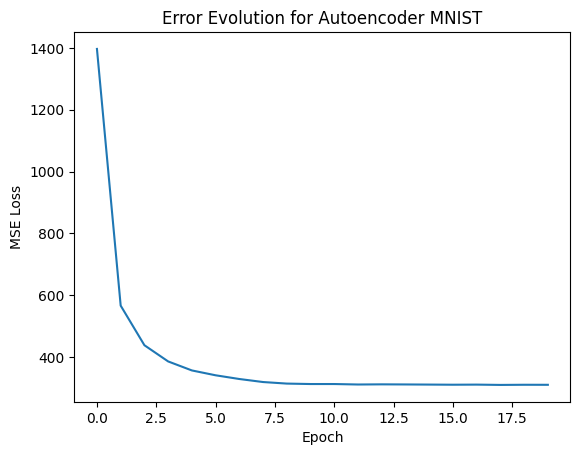

In [ ]:
import matplotlib.pyplot as plt
loss_evolution_autoencoder = th.tensor(loss_evolution_autoencoder)
plt.plot(loss_evolution_autoencoder.numpy())
plt.title("Error Evolution for Autoencoder MNIST")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

In [ ]:
with th.inference_mode():
    training_data=training_data.reshape(training_data.shape[0],784)
    test_data = test_data.reshape(test_data.shape[0],784)
    train_predict= model_autoencoder.forward(training_data)
    test_predict =  model_autoencoder.forward(test_data)

    i_comp = model_autoencoder.predict_i_comp(training_data)
    i_comp_test = model_autoencoder.predict_i_comp(test_data)


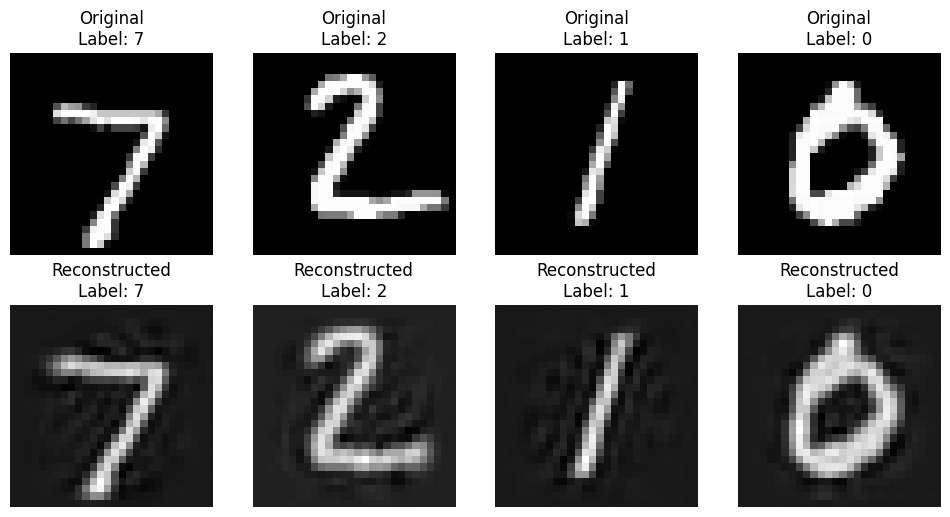

In [ ]:

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    axes[0, i].imshow(test_data[i].reshape(28,28), cmap='gray')
    axes[0, i].set_title(f"Original\nLabel: {test_labels[i]}")
    axes[0, i].axis('off')

    axes[1, i].imshow(test_predict[i].reshape(28,28), cmap='gray')
    axes[1, i].set_title(f"Reconstructed\nLabel: {test_labels[i]}")
    axes[1, i].axis('off')




In [ ]:
class EncoderLinear(nn.Module):
    def __init__(self,input_size):
        super().__init__()

        self.linear = nn.Linear(input_size, 10)



        self.optimizer = th.optim.Adam(self.parameters(), lr=0.0005)
        self.f_loss = nn.CrossEntropyLoss()



    def _make_minibatches(self,training_data, training_labels, minibatch_size):
        mini_batches = []
        label_batches = []

        permutation = th.randperm(training_data.size(0))
        training_data = training_data[permutation]
        training_labels = training_labels[permutation]

        n_minibatches = 0
        for i in range(0, training_data.size(0), minibatch_size):
            mini_batch_data = training_data[i:i+minibatch_size]
            mini_batch_labels = training_labels[i:i+minibatch_size]
            mini_batches.append(mini_batch_data)
            label_batches.append(mini_batch_labels)
            n_minibatches +=1

        return mini_batches, label_batches, n_minibatches

    def forward(self, x):
        x = self.linear(x)
        return x

    def train(self, training_data,training_labels, minibatch_size,number_epochs):
        loss_evolution = []
        for epoca in range(number_epochs):
            mini_batches, labels,n_minibatches = self._make_minibatches(training_data, training_labels, minibatch_size)

            loss_epoch = 0
            for mini_batch in range(n_minibatches):
                outputs = self.forward(mini_batches[mini_batch])

                loss = self.f_loss(outputs, labels[mini_batch])

                loss_epoch+=loss/n_minibatches
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

            loss_evolution.append(loss_epoch)

        return loss_evolution


In [ ]:
modelo_encoder_linear =EncoderLinear(i_comp.shape[1])
loss_encoder_linear = modelo_encoder_linear.train(training_data=i_comp,training_labels=training_labels, minibatch_size=50,number_epochs=10)

tensor(0.5744)


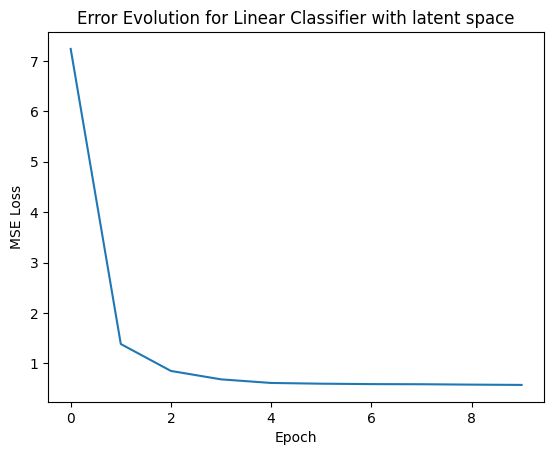

In [ ]:
loss_encoder_linear = th.tensor(loss_encoder_linear)
plt.plot(loss_encoder_linear.numpy())
print(loss_encoder_linear[-1])
plt.title("Error Evolution for Linear Classifier with latent space")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

In [ ]:
with th.inference_mode():
    labels_pred = modelo_encoder_linear.forward(i_comp_test)
    class_predictions = []
    for prediction in labels_pred:

        index_max = th.argmax(prediction)
        class_predictions.append(index_max)


    amount_wrong = 0
    for prediction_index in range(len(class_predictions)):
        if test_labels[prediction_index] != class_predictions[prediction_index]:
            amount_wrong+=1


    accuracy =(len(class_predictions)-amount_wrong)/len(class_predictions)
    print("accuracy:", accuracy*100)

accuracy: 88.75


In [ ]:
training_data=training_data.reshape(training_data.shape[0],784)
test_data=test_data.reshape(test_data.shape[0],784)
modelo_encoder_linear_sin_latente =EncoderLinear(len(training_data[0]))
loss_encoder_linear_sin_latente = modelo_encoder_linear_sin_latente.train(training_data=training_data,training_labels=training_labels, minibatch_size=50,number_epochs=10)

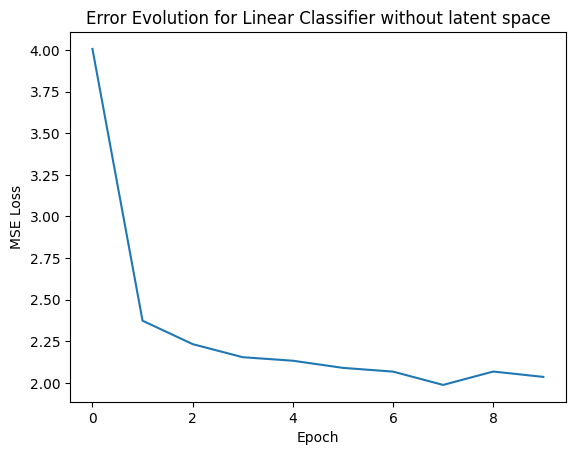

In [ ]:
loss_encoder_linear_sin_latente = th.tensor(loss_encoder_linear_sin_latente)
plt.plot(loss_encoder_linear_sin_latente.numpy())
plt.title("Error Evolution for Linear Classifier without latent space")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

In [ ]:
with th.inference_mode():
    labels_pred = modelo_encoder_linear_sin_latente.forward(test_data)
    class_predictions = []
    for prediction in labels_pred:

        index_max = th.argmax(prediction)
        class_predictions.append(index_max)


    amount_wrong = 0
    for prediction_index in range(len(class_predictions)):
        if test_labels[prediction_index] != class_predictions[prediction_index]:
            amount_wrong+=1


    accuracy =(len(class_predictions)-amount_wrong)/len(class_predictions)
    print("accuracy:", accuracy*100)

accuracy: 88.84
